In [20]:
#Importing packages
import argparse
import os
from torch.utils.data import DataLoader
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import pandas as pd
from chromadb import PersistentClient as PersistentClient
from chromadb.errors import InternalError as CollectionError
import random
import numpy as np

#library functions
import src.dataloading as dataloading
import src.data_vis as data_vis
import src.model_functions as model_functions
import src.loss_functions as loss_functions
import src.models as models
from src.seeds import set_seed


In [28]:
labels_csv = r"camera_data/berryessa_data.csv"

device = 'cuda' 

model_path = 'weights/'
model_name = "sad_loss_model.pth"

load = False
    
data = dataloading.get_data(labels_csv, 'camera_data/images/', replace_images = False, binarize = False)

100%|██████████| 198/198 [00:00<00:00, 4824.88it/s]


In [6]:
g = set_seed()

In [ ]:
labels_csv = r"camera_data/coronado_hills_4pt.json"

device = 'cuda' 

model_path = 'weights/'
model_name = "sad_loss_model.pth"

load = False
    
data = dataloading.get_data(labels_csv, 'camera_data/images/', replace_images = False, binarize = True)

labeled_data = data[data['choice'] > -1]

full_train, _, _ = dataloading.get_train_val_test(data = data, output_csvs=False)

train, val, test = dataloading.get_train_val_test(data = labeled_data, output_csvs=True)

full_train_dataloader, _, _ = dataloading.get_train_val_test_dataloaders(full_train, val, test, generator = g)
train_dataloader, val_dataloader, test_dataloader = dataloading.get_train_val_test_dataloaders(train, val, test, generator = g)

100%|██████████| 7488/7488 [00:01<00:00, 6882.42it/s]


In [ ]:
encoder = models.create_encoder()
encoder.to(device)
encoder.load_state_dict(torch.load('weights/model_weights_camera_10-27-25.pth', map_location=device, weights_only=True));

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Instantiating the training settings

In [ ]:
loss_func = loss_functions.DeepSADLoss(model=encoder, train_data=train_dataloader, device = device, eta = 10)
optimizer = optim.Adam(encoder.parameters(), lr=1e-6, weight_decay=1e-7) 
num_epochs = 1

Training the model

In [ ]:
if load:
    encoder.load_state_dict(torch.load(os.path.join(model_path, model_name), map_location=device, weights_only=True))
    losses = []
else:
    losses = model_functions.train_model(encoder, train_data=full_train_dataloader, 
                                    num_epochs=num_epochs, loss_func=loss_func, 
                                    optimizer=optimizer, name = 'sad_loss_model.pth', path = 'weights/', device=device)

Text(0.5, 1.0, 'Image to Embeddings Model Losses')

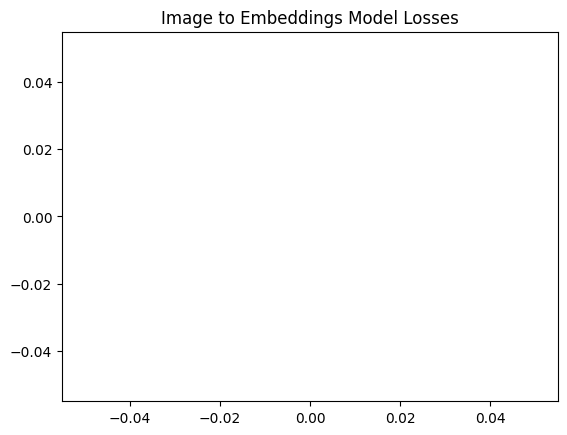

In [ ]:
import matplotlib.pyplot as plt

plt.plot(list(range(len(losses))), losses)
plt.title("Image to Embeddings Model Losses")

Saving the embeddings generated by this model

In [ ]:
client = PersistentClient(path="embedding_data/") 

try:
    client.delete_collection(name="train_embeddings")
except Exception:
    pass

try:
    client.delete_collection(name="val_embeddings")
except Exception:
    pass


dataloading.save_full_embeddings(encoder, train_dataloader, 
                        "train_embeddings", persist_directory = "embedding_data/", 
                        device = device)


dataloading.save_full_embeddings(encoder, val_dataloader, 
                        "val_embeddings", persist_directory = "embedding_data/", 
                        device = device)
    
    
#Embeddings of training data, used to train the classification head
train_embeddings, train_labels, train_img_urls, train_a_ids = dataloading.load_full_embeddings(train, "train_embeddings", persist_directory = "embedding_data/")
train_embedding_dataloader = dataloading.embedding_to_dataloader(train_embeddings, train_labels, batch_size=32, generator = g)

#Embeddings of validation data, used to display results
val_embeddings, val_labels, _, _ = dataloading.load_full_embeddings(val, "val_embeddings", persist_directory = "embedding_data/")

Visualizing the first two principal axes of the embedding space

In [ ]:
reduced_embeddings, labels = model_functions.reduce_pca(train_embeddings, train_labels, dimensions=4)

In [ ]:
pd.DataFrame(reduced_embeddings).to_csv("camera_data/reduced_embeddings_deepsad.csv", index=False)

Text(0.5, 1.0, 'First two axes of embedding space generated by DeepSAD loss model')

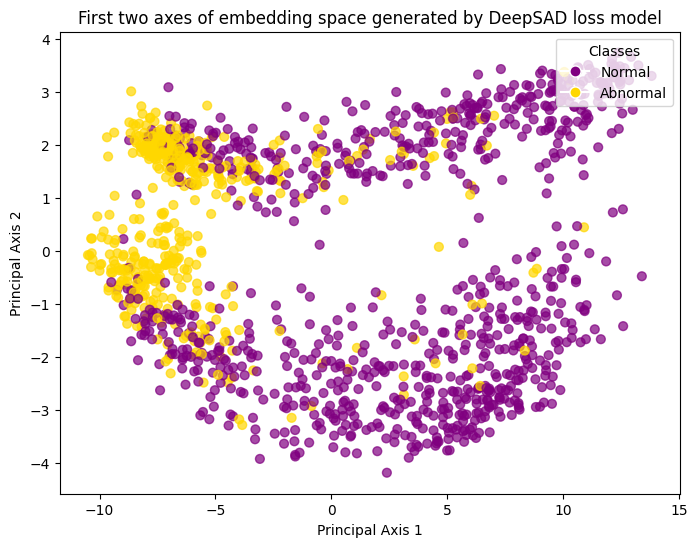

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax = data_vis.plot_data(reduced_embeddings, labels, pcx = 1, pcy = 2, ax=ax)
ax.set_title("First two axes of embedding space generated by DeepSAD loss model")

Training classification head

In [ ]:
losses = []

classification_head = models.ClassificationHead(num_classes=2)
classification_head.to(device)

head_criterion = nn.CrossEntropyLoss()
head_optimizer = optim.Adam(classification_head.parameters(), lr=1e-3) # Optimize only the new head

losses = model_functions.train_classification_head(classification_head, train_embedding_dataloader, num_epochs=10, criterion=head_criterion, optimizer=head_optimizer, 
                           device=device, model_name=model_name, model_path = "weights/", save=True)

#Report training and validation accuracy
classification_head.eval()

Processing batches in epoch 7:  66%|██████▌   | 29/44 [00:02<00:01, 10.79it/s]


KeyboardInterrupt: 

Testing classification head outputs

In [ ]:
train_embeddings_tensor = torch.Tensor(train_embeddings.to_numpy()).to(device)
val_embeddings_tensor = torch.Tensor(val_embeddings.to_numpy()).to(device)

train_labels_tensor = torch.Tensor(train_labels.to_numpy()).to(device)
val_labels_tensor = torch.Tensor(val_labels.to_numpy()).to(device)


train_outputs = classification_head(train_embeddings_tensor)
val_outputs = classification_head(val_embeddings_tensor)

print(f"Training accuracy: {(torch.argmax(train_outputs, dim = -1) == train_labels_tensor).float().mean().item()}")
print(f"Validation accuracy: {(torch.argmax(val_outputs, dim = -1) == val_labels_tensor).float().mean().item()}")

Training accuracy: 0.9243515729904175
Validation accuracy: 0.9136068820953369
